In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [3]:
#  imports & setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc
import time

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
from src.data import build_transforms, ImageOnlyDataset
from src.models import build_vision_backbone
from src.train import train_one_epoch_image, validate_image



main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs", "exp9")

df = pd.read_csv(data_csv)

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error

# paths
main_folder = "../.."
img_oof_swin_path  = os.path.join(main_folder, "outputs", "exp5", "oof_detail.csv")
img_off_effB4_path = os.path.join(main_folder, "outputs", "exp8", "oof_detail.csv")  

img_swin_oof  = pd.read_csv(img_oof_swin_path)   # columns: Id, fold, ytrue, oof_pred, 
img_effB4_oof = pd.read_csv(img_off_effB4_path)  # same column



In [6]:
# check for alignment of Ids and folds
img_swin_map = img_swin_oof[["Id", "fold"]].sort_values("Id").reset_index(drop=True)
img_effB4_map = img_effB4_oof[["Id", "fold"]].sort_values("Id").reset_index(drop=True)

assert img_swin_map.equals(img_effB4_map), "Fold assignment differs! RMSE per fold will be wrong."


In [7]:
assert set(img_swin_oof["Id"]) == set(img_effB4_oof["Id"]), "IDs differ!"

In [8]:

# inner join on Id to  alignment
oof = img_swin_oof.merge(
    img_effB4_oof[["Id", "oof_pred"]].rename(columns={"oof_pred": "img_effB4_oof"}),
    on="Id",
    how="inner",
)

y_true = oof["ytrue"].values
img_swin_pred = oof["oof_pred"].values
img_effB4_pred = oof["img_effB4_oof"].values

In [9]:
img_swin_rmse = root_mean_squared_error(y_true, img_swin_pred)
img_effB4_rmse = root_mean_squared_error(y_true, img_effB4_pred)
print("Image SWIN OOF RMSE:", img_swin_rmse)
print("Image EffB4 OOF RMSE:", img_effB4_rmse)

Image SWIN OOF RMSE: 17.60001884040648
Image EffB4 OOF RMSE: 18.682241951546622


In [ ]:
from src.utils import late_fusion_from_oof

# oof
oof_fused, oof_rmse, info = late_fusion_from_oof(
    oof,
    img_col="oof_pred",
    tab_col="img_effB4_oof", # it is image predictions not tabular data
    y_col="ytrue",
    fold_col="fold",
    mode="simple",      # or "simple" | "weighted", simple is just average 
)

print("Global OOF RMSE:", oof_rmse)
print("Weights:", info["weight_a"], info["weight_b"])
print("Fold-wise RMSE:", info["fold_rmse"])
print("Avg:", info["fold_rmse_mean"], "Std:", info["fold_rmse_std"])



Global OOF RMSE: 17.768810982740224
Weights: 0.5 0.5
Fold-wise RMSE: {1: 17.918374923869525, 2: 17.974696509994903, 3: 17.369443137102643, 4: 17.699386359791582, 5: 17.875209252193336}
Avg: 17.767422036590396 Std: 0.21926405227734522


In [11]:
oof_fused, oof_rmse, info = late_fusion_from_oof(
    oof,
    img_col="oof_pred",
    tab_col="img_effB4_oof",
    y_col="ytrue",
    fold_col="fold",
    mode="weighted",      # or "simple" | "weighted", simple is just average 
    n_grid=101,
)

print("Global OOF RMSE:", oof_rmse)
print("Weights:", info["weight_a"], info["weight_b"])
print("Fold-wise RMSE:", info["fold_rmse"])
print("Avg:", info["fold_rmse_mean"], "Std:", info["fold_rmse_std"])

oof_fused = oof_fused.rename(columns={"oof_pred": "swin_oof"})
oof_fused["abs_err"] = (oof_fused["ytrue"] - oof_fused["final_pred"]).abs()
# save new OOF 
oof_fused.to_csv(os.path.join(main_folder, "outputs", "exp9", "swin_effB4_weighted_oof_detail.csv"),
                 index=False)
oof_fused.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(main_folder, "outputs", "exp9",  "EffB4_swin_top50_errors.csv"), index=False
)

Global OOF RMSE: 17.569230014516165
Weights: 0.86 0.14
Fold-wise RMSE: {1: 17.599105828776985, 2: 17.75599299180808, 3: 17.237006101447147, 4: 17.56050829357812, 5: 17.688858463866996}
Avg: 17.568294335895466 Std: 0.17918055654416115


In [19]:
import pandas
df = pd.read_csv(out_dir+"/swin_effB4_weighted_oof_detail.csv")

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.final_pred)**2).mean() ** 0.5
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 17.8638 (n=1983)
Fold 2 OOF RMSE: 17.7339 (n=1983)
Fold 3 OOF RMSE: 17.1237 (n=1982)
Fold 4 OOF RMSE: 17.3722 (n=1982)
Fold 5 OOF RMSE: 17.8852 (n=1982)


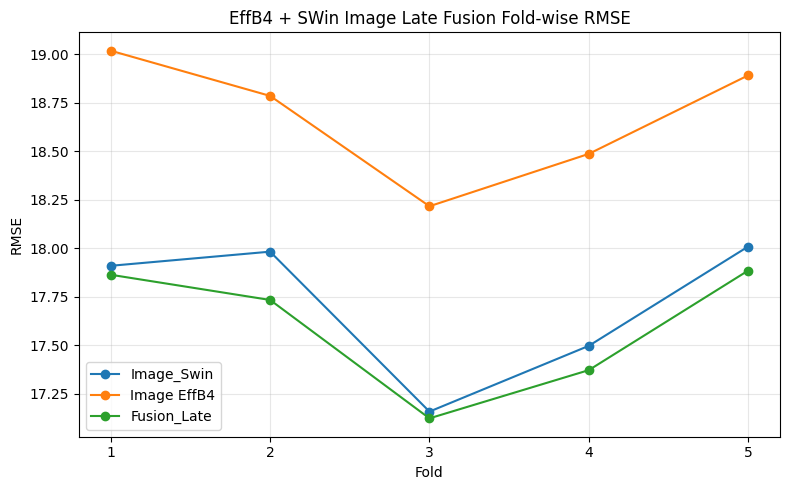

In [20]:
from src.plot import plot_foldwise_rmse
df = pd.read_csv(out_dir + "/swin_effB4_weighted_oof_detail.csv")

rmse_results = plot_foldwise_rmse(
    df,
    y_col="ytrue",
    pred_cols={
        "Image_Swin": "swin_oof",
        "Image EffB4": "img_effB4_oof",
        "Fusion_Late": "final_pred"
    },
    fold_col="fold",
    title="EffB4 + SWin Image Late Fusion Fold-wise RMSE",
)


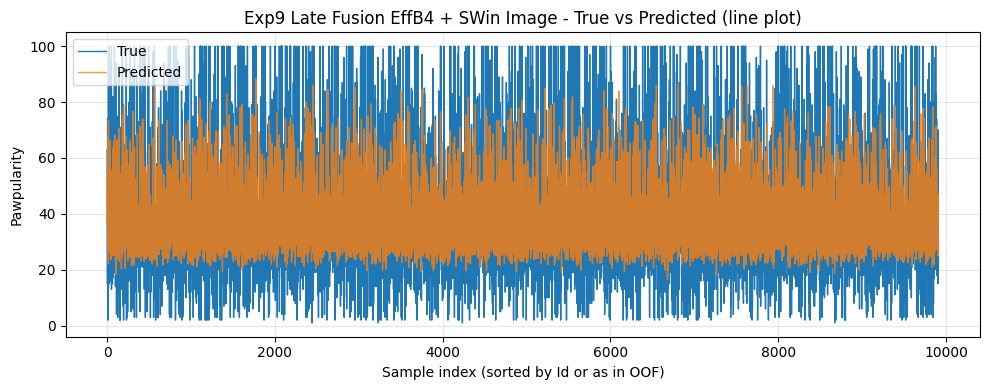

In [21]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

oof_df = df.rename(columns={"final_pred": "oof_pred"})


# Plots
plot_oof_true_pred_lines(oof_df, title_prefix="Exp9 Late Fusion EffB4 + SWin Image")

Image Swin OOF RMSE: 17.7147
EffB4  OOF RMSE: 18.6822
Late Fusion OOF RMSE: 17.5983


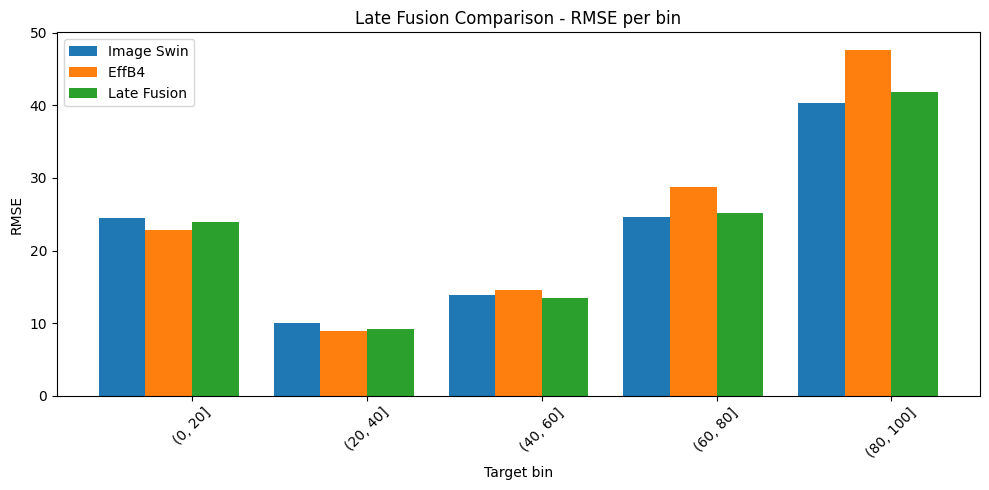

In [22]:
bins = [0, 20, 40, 60, 80, 100]
from src.plot import compare_oof_by_bins_multi

summary, overall = compare_oof_by_bins_multi(
    oof_df,
    bins=bins,
    y_col="ytrue",
    pred_cols={
        "Image Swin": "swin_oof",
        "EffB4 ": "img_effB4_oof",
        "Late Fusion": "oof_pred"
    },
    title_prefix="Late Fusion Comparison"
)

In [23]:
summary.head()

,bin,count,Image Swin_rmse,EffB4 _rmse,Late Fusion_rmse
0,"(0, 20]",1417,24.496437,22.815533,23.895821
1,"(20, 40]",5119,9.970236,8.891782,9.245733
2,"(40, 60]",2088,13.859223,14.525071,13.501655
3,"(60, 80]",727,24.577702,28.761188,25.228700
4,"(80, 100]",561,40.300325,47.678782,41.789151


In [24]:
err_df = pd.read_csv(os.path.join(main_folder, "outputs", "exp9",  "EffB4_swin_top50_errors.csv"))
err_df = err_df.rename(columns={"final_pred": "oof_pred"})

In [25]:
err_df.head()

,Id,fold,ytrue,swin_oof,abs_err,img_effB4_oof,oof_pred
0,4c1e05895368c997fdd709bbd1ac3dae,2,2,89.910660,83.220325,70.367599,85.220325
1,054cef9194f1a4513dc0965893b589bf,3,2,81.356499,76.670003,70.162766,78.670003
2,cda998949ee096e41e190f767561960a,5,12,82.755836,73.837285,95.595207,85.837285
3,346650fd7c4fcdcbd7a119436881e52a,3,3,77.213402,73.491637,74.206047,76.491637
4,4435d6f98ad72782ca0cf61f946b016d,5,100,25.190582,73.344359,31.294994,26.655641


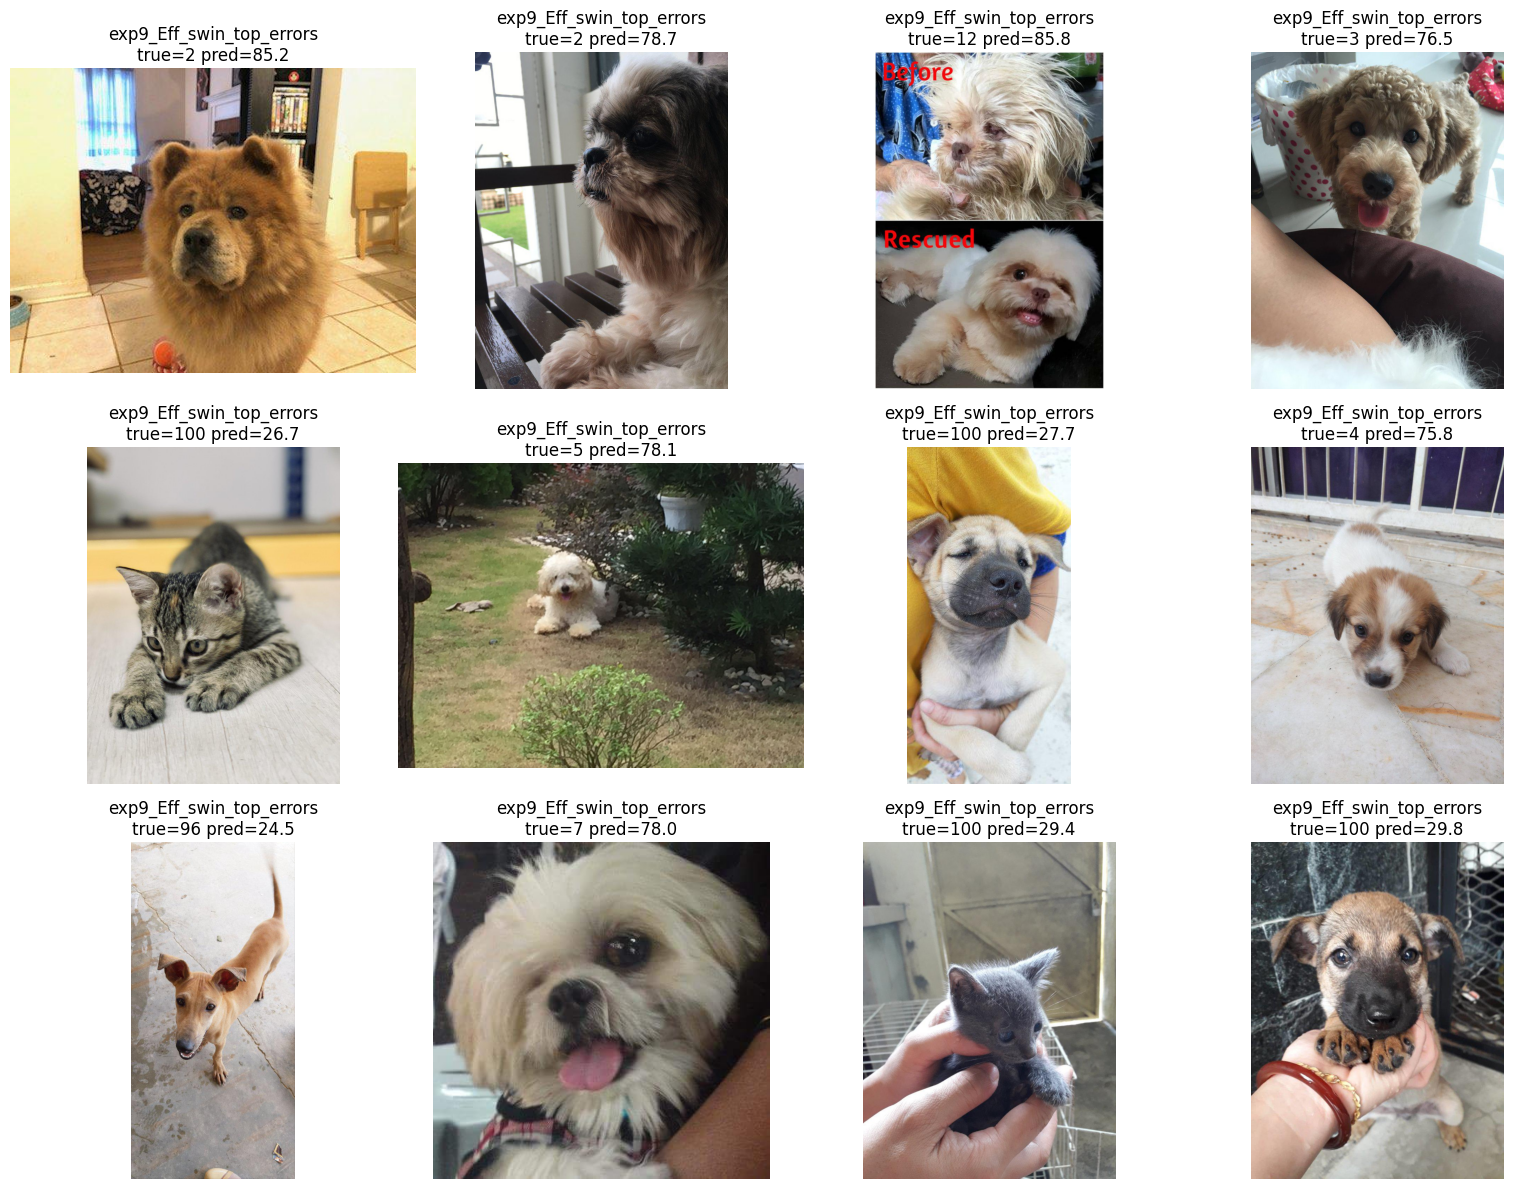

In [26]:
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="exp9_Eff_swin_top_errors")

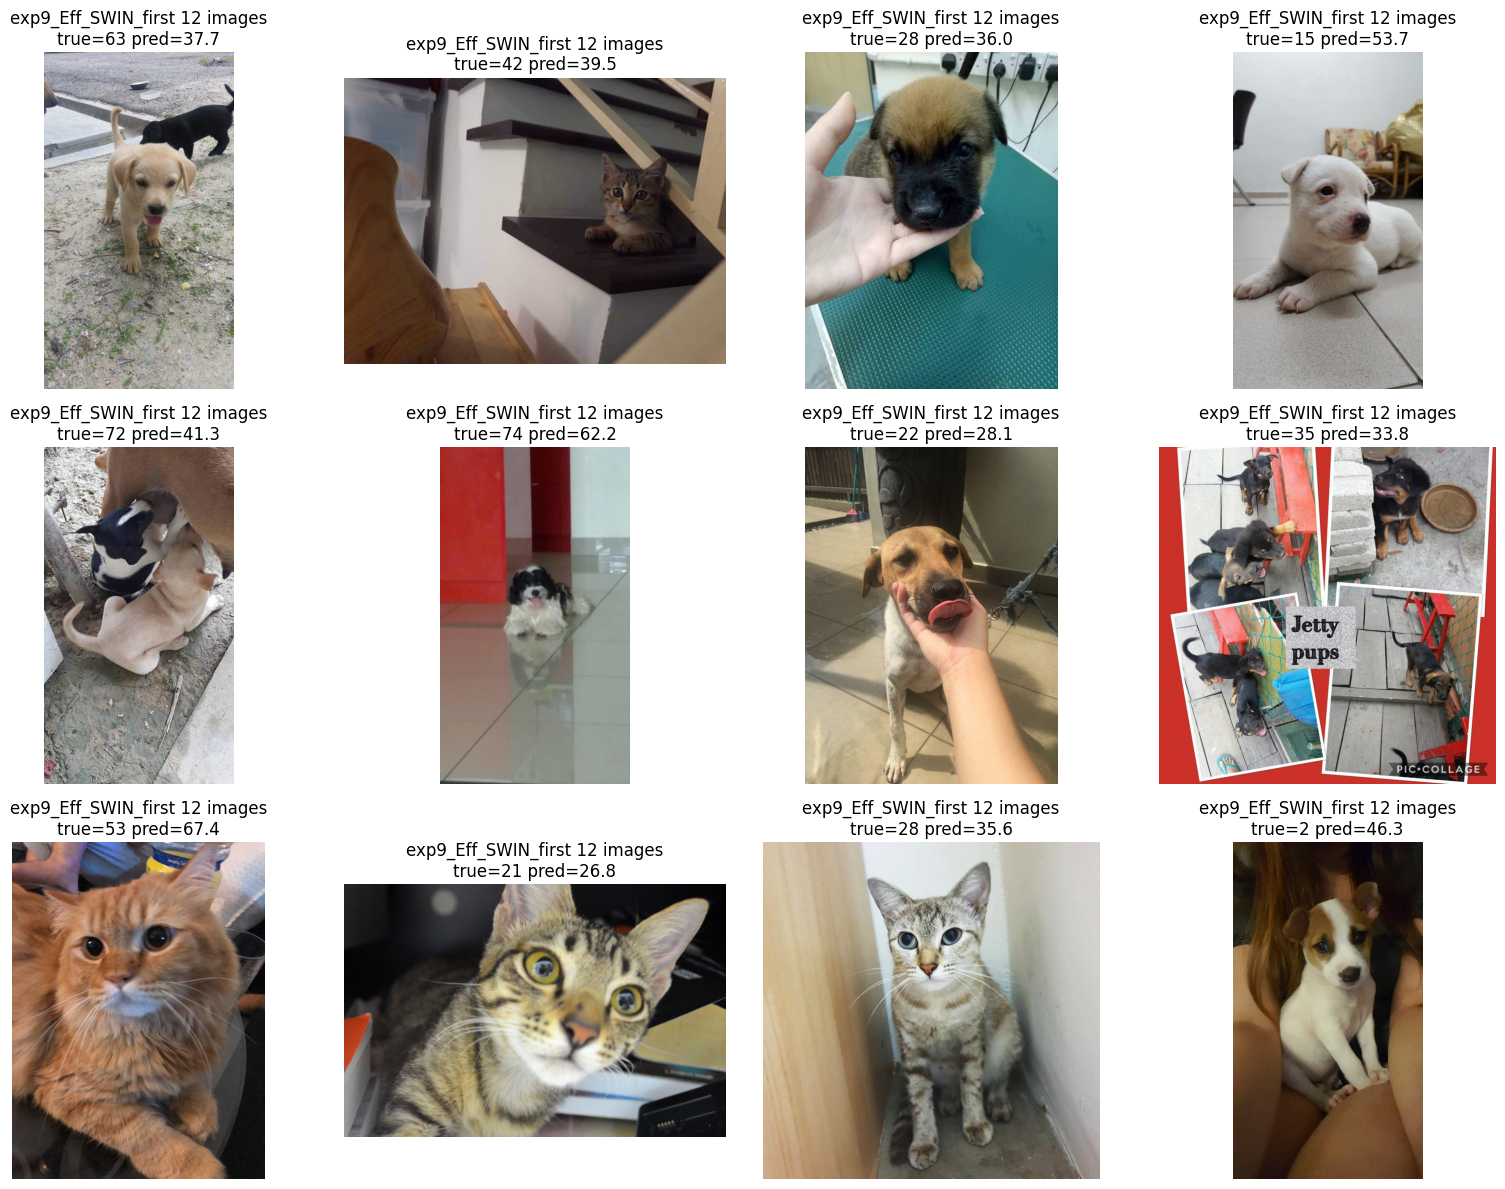

In [27]:
oof_df = oof_df.rename(columns={"final_pred": "oof_pred"})
show_images_grid(oof_df, img_folder, n=12, title_prefix="exp9_Eff_SWIN_first 12 images")